# Schwarzschild Metric Workflow

This notebook builds a clear symbolic and numeric workflow for the Schwarzschild metric:

- Define coordinates and metric
- Compute Christoffel symbols, Riemann, Ricci, and Einstein tensors symbolically
- Derive geodesic equations symbolically and convert to numeric ODEs
- Numerically integrate geodesics for different initial conditions and plot them in 2D & 3D
- Show embedding diagram and curvature visualizations

All symbolic objects are printed at each step for verification. Plots use matplotlib and plotly for interactivity.

**Notes**: Run the whole notebook top-to-bottom. Install required packages if needed: `sympy`, `numpy`, `scipy`, `matplotlib`, `plotly`.

In [14]:
# Install required packages (uncomment and run if needed)
# !pip install sympy numpy scipy matplotlib plotly

print('Ready to proceed with symbolic and numeric computations.')

Ready to proceed with symbolic and numeric computations.


## 1) Coordinates and Metric

We'll use Schwarzschild coordinates $(t,r,$\theta$,hi)$ and signature `(-,+,+,+)`. The Schwarzschild metric (geometric units $G=c=1$) is:

$$ds^2 = -eft(1-frac{2M}{r}
ight)dt^2 + eft(1-frac{2M}{r}
ight)^{-1}dr^2 + r^2 d	heta^2 + r^2 in^2	heta  dhi^2.$$

We'll declare symbolic coordinates and parameters and then the metric tensor as a SymPy Matrix.

In [15]:
import sympy as sp
# Coordinates and parameter
t, r, th, ph, M = sp.symbols('t r th ph M')
coords = (t, r, th, ph)
# Metric components (Schwarzschild, signature - + + +)
f = 1 - 2*M/r
g = sp.zeros(4)
g[0,0] = -f
g[1,1] = 1/f
g[2,2] = r**2
g[3,3] = r**2 * sp.sin(th)**2
g = sp.Matrix(g)
# Print metric
print('Coordinates:', coords)
print('\nMetric g_ab (matrix form):')
sp.pprint(g)
# Symbolic inverse metric
g_inv = sp.simplify(g.inv())
print('\nInverse metric g^ab:')
sp.pprint(g_inv)

Coordinates: (t, r, th, ph)

Metric g_ab (matrix form):
⎡2⋅M                                ⎤
⎢─── - 1      0      0        0     ⎥
⎢ r                                 ⎥
⎢                                   ⎥
⎢             1                     ⎥
⎢   0     ─────────  0        0     ⎥
⎢           2⋅M                     ⎥
⎢         - ─── + 1                 ⎥
⎢            r                      ⎥
⎢                                   ⎥
⎢                     2             ⎥
⎢   0         0      r        0     ⎥
⎢                                   ⎥
⎢                         2    2    ⎥
⎣   0         0      0   r ⋅sin (th)⎦

Inverse metric g^ab:
⎡   r                              ⎤
⎢───────     0      0        0     ⎥
⎢2⋅M - r                           ⎥
⎢                                  ⎥
⎢         -2⋅M + r                 ⎥
⎢   0     ────────  0        0     ⎥
⎢            r                     ⎥
⎢                                  ⎥
⎢                   1              ⎥
⎢   0        0     

## 2) Christoffel Symbols

Compute the Christoffel symbols using the metric: $$\Gamma^a_{\ bc} = \frac{1}{2} g^{ad}(\partial_b g_{dc} + \partial_c g_{db} - \partial_d g_{bc}).$$
We'll compute and print the non-zero components.

In [16]:
# Christoffel symbols computation
n = 4
Gamma = [[[0 for _ in range(n)] for _ in range(n)] for _ in range(n)]
for a in range(n):
    for b in range(n):
        for c in range(n):
            term = 0
            for d in range(n):
                term += g_inv[a,d]*(sp.diff(g[d,c], coords[b]) + sp.diff(g[d,b], coords[c]) - sp.diff(g[b,c], coords[d]))
            Gamma[a][b][c] = sp.simplify(sp.Rational(1,2)*term)

# Print non-zero Christoffel symbols
print('Non-zero Christoffel symbols (\nGamma^a_{bc}):')
for a in range(n):
    for b in range(n):
        for c in range(n):
            if Gamma[a][b][c] != 0:
                print(f'Gamma^{a}_{{{b}{c}}} =')
                sp.pprint(Gamma[a][b][c])
                print()


Non-zero Christoffel symbols (
Gamma^a_{bc}):
Gamma^0_{01} =
     M      
────────────
r⋅(-2⋅M + r)

Gamma^0_{10} =
     M      
────────────
r⋅(-2⋅M + r)

Gamma^1_{00} =
M⋅(-2⋅M + r)
────────────
      3     
     r      

Gamma^1_{11} =
     M     
───────────
r⋅(2⋅M - r)

Gamma^1_{22} =
2⋅M - r

Gamma^1_{33} =
             2    
(2⋅M - r)⋅sin (th)

Gamma^2_{12} =
1
─
r

Gamma^2_{21} =
1
─
r

Gamma^2_{33} =
-sin(2⋅th) 
───────────
     2     

Gamma^3_{13} =
1
─
r

Gamma^3_{23} =
   1   
───────
tan(th)

Gamma^3_{31} =
1
─
r

Gamma^3_{32} =
   1   
───────
tan(th)



## 3) Riemann Tensor

Riemann tensor: $$R^a_{\ bcd} = \partial_c \Gamma^a_{\ bd} - \partial_d \Gamma^a_{\ bc} + \Gamma^a_{\ ce}\Gamma^e_{\ bd} - \Gamma^a_{\ de}\Gamma^e_{\ bc}.$$
We will compute and print representative non-zero components (symbolically).

In [17]:
# Compute Riemann tensor R^a_{bcd}
Riemann = [[[[0 for _ in range(n)] for _ in range(n)] for _ in range(n)] for _ in range(n)]
for a in range(n):
    for b in range(n):
        for c in range(n):
            for d in range(n):
                term = sp.diff(Gamma[a][b][d], coords[c]) - sp.diff(Gamma[a][b][c], coords[d])
                sum_term = 0
                for e in range(n):
                    sum_term += Gamma[a][c][e]*Gamma[e][b][d] - Gamma[a][d][e]*Gamma[e][b][c]
                Riemann[a][b][c][d] = sp.simplify(term + sum_term)

# Print a limited number of non-zero components
print('Representative non-zero Riemann components:')
count = 0
stop = False
for a in range(n):
    if stop: break
    for b in range(n):
        if stop: break
        for c in range(n):
            if stop: break
            for d in range(n):
                val = Riemann[a][b][c][d]
                if val != 0:
                    print(f'R^{a}_{{{b}{c}{d}}} =')
                    sp.pprint(val)
                    print()
                    count += 1
                    if count >= 20:
                        stop = True
                        break


Representative non-zero Riemann components:
R^0_{101} =
     2⋅M     
─────────────
 2           
r ⋅(-2⋅M + r)

R^0_{110} =
    2⋅M     
────────────
 2          
r ⋅(2⋅M - r)

R^0_{202} =
-M 
───
 r 

R^0_{220} =
M
─
r

R^0_{303} =
      2     
-M⋅sin (th) 
────────────
     r      

R^0_{330} =
     2    
M⋅sin (th)
──────────
    r     

R^1_{001} =
2⋅M⋅(-2⋅M + r)
──────────────
       4      
      r       

R^1_{010} =
2⋅M⋅(2⋅M - r)
─────────────
      4      
     r       

R^1_{212} =
-M 
───
 r 

R^1_{221} =
M
─
r

R^1_{313} =
      2     
-M⋅sin (th) 
────────────
     r      

R^1_{331} =
     2    
M⋅sin (th)
──────────
    r     

R^2_{002} =
M⋅(2⋅M - r)
───────────
     4     
    r      

R^2_{020} =
M⋅(-2⋅M + r)
────────────
      4     
     r      

R^2_{112} =
      M      
─────────────
 2           
r ⋅(-2⋅M + r)

R^2_{121} =
     M      
────────────
 2          
r ⋅(2⋅M - r)

R^2_{323} =
       2    
2⋅M⋅sin (th)
────────────
     r      

R^2_{332} =
        2  

## 4) Ricci Tensor and Scalar

Ricci tensor: $R_{ab} = R^c{}_{acb}$. Ricci scalar: $R = g^{ab}R_{ab}$. For vacuum Schwarzschild, $R_{ab}=0$. We'll compute to verify.

In [18]:
# Compute Ricci tensor R_ab and scalar R
Ricci = [[0 for _ in range(n)] for _ in range(n)]
for a in range(n):
    for b in range(n):
        s = 0
        for c in range(n):
            s += Riemann[c][a][c][b]
        Ricci[a][b] = sp.simplify(s)

# Print Ricci (should be zero for Schwarzschild vacuum)
print('Ricci tensor R_ab:')
nonzero = False
for a in range(n):
    for b in range(n):
        if Ricci[a][b] != 0:
            nonzero = True
            print(f'R_{a}{b} =')
            sp.pprint(Ricci[a][b])
if not nonzero:
    print('All components are zero (vacuum verified).')

# Ricci scalar
R_scalar = 0
for a in range(n):
    for b in range(n):
        R_scalar += g_inv[a,b]*Ricci[a][b]
R_scalar = sp.simplify(R_scalar)
print('\nRicci scalar R =')
sp.pprint(R_scalar)


Ricci tensor R_ab:
All components are zero (vacuum verified).

Ricci scalar R =
0


## 5) Einstein Tensor

Compute the Einstein tensor $G_{ab} = R_{ab} - \tfrac{1}{2} g_{ab} R$. For Schwarzschild vacuum $G_{ab}=0$.

In [19]:
# Einstein tensor G_ab
G = [[0 for _ in range(n)] for _ in range(n)]
for a in range(n):
    for b in range(n):
        G[a][b] = sp.simplify(Ricci[a][b] - sp.Rational(1,2)*g[a,b]*R_scalar)

print('Einstein tensor G_ab (should be zero):')
nonzeroG = False
for a in range(n):
    for b in range(n):
        if G[a][b] != 0:
            nonzeroG = True
            print(f'G_{a}{b} =')
            sp.pprint(G[a][b])
if not nonzeroG:
    print('All Einstein tensor components are zero (vacuum).')


Einstein tensor G_ab (should be zero):
All Einstein tensor components are zero (vacuum).


## 6) Geodesic Equations

Geodesic equation: $$\frac{d^2 x^a}{d\lambda^2} + \Gamma^a_{\ bc} \frac{dx^b}{d\lambda}\frac{dx^c}{d\lambda} = 0.$$
We'll derive expressions for the second-order ODEs and then convert to first-order system for numerical integration. We'll demonstrate numerical integration for timelike and null geodesics.

In [20]:
# Define symbolic variables for derivatives along affine parameter lambda
V = sp.symbols('V0:4')
d2 = [0]*n
for a in range(n):
    sum_term = 0
    for b in range(n):
        for c in range(n):
            sum_term += Gamma[a][b][c]*V[b]*V[c]
    d2[a] = sp.simplify(-sum_term)

print('Geodesic second-derivative components (symbolic, in terms of V0..V3):')
for a in range(n):
    print(f'd2 x^{a}/dlambda^2 =')
    sp.pprint(d2[a])
    print()


Geodesic second-derivative components (symbolic, in terms of V0..V3):
d2 x^0/dlambda^2 =
 2⋅M⋅V₀⋅V₁ 
───────────
r⋅(2⋅M - r)

d2 x^1/dlambda^2 =
    2          2       2  2    3          2 ⎛  2     2    2    ⎞
M⋅V₀ ⋅(2⋅M - r)  - M⋅V₁ ⋅r  - r ⋅(2⋅M - r) ⋅⎝V₂  + V₃ ⋅sin (th)⎠
────────────────────────────────────────────────────────────────
                           3                                    
                          r ⋅(2⋅M - r)                          

d2 x^2/dlambda^2 =
              2          
  2⋅V₁⋅V₂   V₃ ⋅sin(2⋅th)
- ─────── + ─────────────
     r            2      

d2 x^3/dlambda^2 =
      ⎛      V₂⋅r  ⎞ 
-2⋅V₃⋅⎜V₁ + ───────⎟ 
      ⎝     tan(th)⎠ 
─────────────────────
          r          



### 6b) Numeric ODE setup

Convert geodesic equations to a first-order system for numeric ODE integration using `scipy.integrate.solve_ivp`. We'll implement functions for timelike (massive particle) and null (photon) geodesics. We'll present examples exploring different initial positions and velocities and plot trajectories in 3D.

In [21]:
import numpy as np
from scipy.integrate import solve_ivp

# Numeric Christoffel evaluator using the symbolic Gamma expressions
def christoffel_numeric(x_vec, M_val):
    t_val, r_val, th_val, ph_val = x_vec
    subs = {t: t_val, r: r_val, th: th_val, ph: ph_val, M: M_val}
    Gnum = np.zeros((4,4,4))
    for a in range(4):
        for b in range(4):
            for c in range(4):
                val = Gamma[a][b][c]
                if val != 0:
                    Gnum[a,b,c] = float(val.subs(subs))
    return Gnum

# First-order ODE system for geodesics: state = [t,r,th,ph, dt/dl, dr/dl, dth/dl, dph/dl]
def geodesic_odes(lambda_val, state, M_val):
    x = state[:4]
    v = state[4:]
    Gnum = christoffel_numeric(x, M_val)
    dv = np.zeros(4)
    for a in range(4):
        s = 0.0
        for b in range(4):
            for c in range(4):
                s += Gnum[a,b,c]*v[b]*v[c]
        dv[a] = -s
    return np.concatenate([v, dv])

# Helper to create initial state with conserved energy E and angular momentum L for equatorial plane
def initial_state_equatorial(r0, E, L, M_val):
    # Set initial theta = pi/2, phi=0, and initial dr/dl = 0
    th0 = np.pi/2
    ph0 = 0.0
    t0 = 0.0
    # For equatorial plane, set dphi/dl from L and dt/dl from E via conserved quantities
    dph_dl = L / r0**2
    dt_dl = E / (1 - 2*M_val/r0)
    dr_dl = 0.0
    dth_dl = 0.0
    state = np.array([t0, r0, th0, ph0, dt_dl, dr_dl, dth_dl, dph_dl], dtype=float)
    return state

print('Numeric geodesic ODEs ready.')

Numeric geodesic ODEs ready.


## 7) Example: Integrate and plot geodesics

We'll integrate several geodesics for different initial radii and angular momenta. We'll plot the orbits in 3D Cartesian coordinates (spatial slice) and produce an interactive Plotly figure.

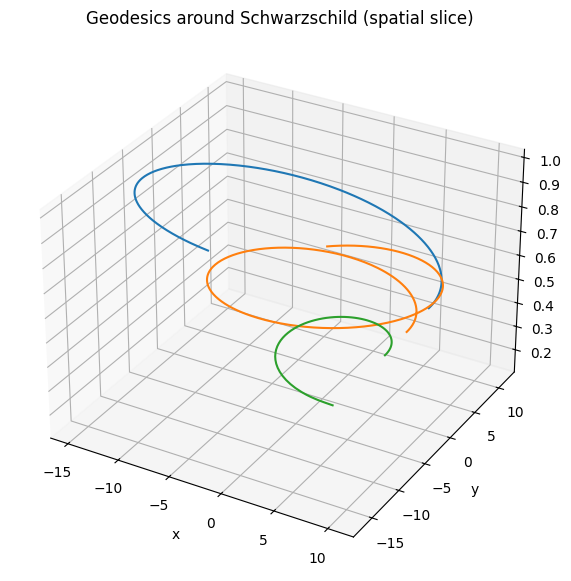

In [22]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import plotly.graph_objects as go

Mval = 1.0
def to_cartesian(r_vals, th_vals, ph_vals):
    x = r_vals * np.sin(th_vals) * np.cos(ph_vals)
    y = r_vals * np.sin(th_vals) * np.sin(ph_vals)
    z = r_vals * np.cos(th_vals)
    return x, y, z

# Integrate a few geodesics with different E, L
solns = []
initials = [ (10, 0.95, 4.0), (8, 0.98, 3.8), (6, 0.999, 3.5) ]  # (r0, E, L)
for r0, E, L in initials:
    state0 = initial_state_equatorial(r0, E, L, Mval)
    lam_span = (0, 200)
    sol = solve_ivp(lambda lam, y: geodesic_odes(lam, y, Mval), lam_span, state0, max_step=0.5, rtol=1e-8)
    solns.append(sol)

# Plot in 3D (matplotlib)
fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')
for sol in solns:
    r_sol = sol.y[1]
    th_sol = sol.y[2]
    ph_sol = sol.y[3]
    x, y, z = to_cartesian(r_sol, th_sol, ph_sol)
    ax.plot(x, y, z)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.set_title('Geodesics around Schwarzschild (spatial slice)')
plt.show()

# Interactive 3D with plotly
fig2 = go.Figure()
for sol in solns:
    r_sol = sol.y[1]
    th_sol = sol.y[2]
    ph_sol = sol.y[3]
    x, y, z = to_cartesian(r_sol, th_sol, ph_sol)
    fig2.add_trace(go.Scatter3d(x=x, y=y, z=z, mode='lines'))
fig2.update_layout(scene=dict(xaxis_title='x', yaxis_title='y', zaxis_title='z'), title='Interactive Geodesics')
fig2.show()

## 8) Embedding Diagram (optional)

Create an embedding diagram for the equatorial spatial slice (t=const, theta=pi/2). Numerical integration of dz/dr = sqrt(1/(1-2M/r) - 1) gives the surface of revolution visualization.

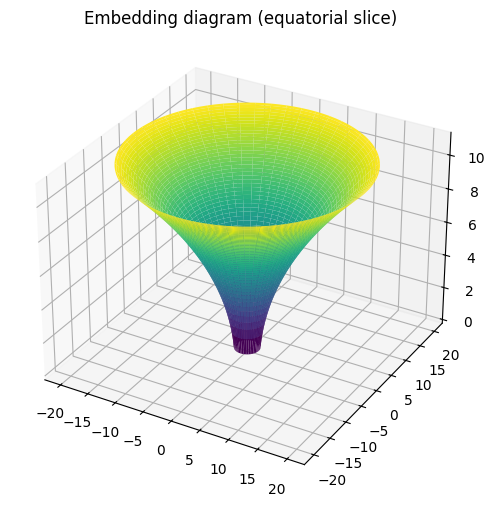

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def embedding_z(r_vals, M_val):
    return np.sqrt(1/(1-2*M_val/r_vals) - 1)

r_grid = np.linspace(2.1, 20, 200)
z_vals = np.zeros_like(r_grid)
for i in range(1, len(r_grid)):
    dr = r_grid[i] - r_grid[i-1]
    z_vals[i] = z_vals[i-1] + embedding_z((r_grid[i]+r_grid[i-1])/2, Mval)*dr

theta = np.linspace(0, 2*np.pi, 100)
R, TH = np.meshgrid(r_grid, theta)
Z = np.tile(z_vals, (len(theta),1))
X = R * np.cos(TH)
Y = R * np.sin(TH)

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Z, cmap='viridis')
ax.set_title('Embedding diagram (equatorial slice)')
plt.show()

## 9) Final notes and next steps

This notebook produced symbolic derivations of key tensors, verified vacuum Einstein equations, and integrated sample geodesics with visualizations.

Next steps: compute tidal forces, add Kerr metric, plot effective potentials, or compute light deflection/observables.